In [1]:
# ============================================================================
# EV CHARGING - MODEL TRAINING PIPELINE
# Baseline 1: GBTRegressor (thay thế XGBoost)
# Baseline 2: Linear Regression
# ============================================================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import GBTRegressor, LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd
import time

# Spark session
spark = SparkSession.builder \
    .appName("EV_Charging_Model_Training") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print("="*80)
print("MODEL TRAINING PIPELINE - EV CHARGING DATASET")
print("="*80)

26/04/13 14:03:14 WARN Utils: Your hostname, ax2 resolves to a loopback address: 127.0.1.1; using 192.168.40.130 instead (on interface ens33)
26/04/13 14:03:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/13 14:03:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


MODEL TRAINING PIPELINE - EV CHARGING DATASET


26/04/13 14:03:33 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [2]:
# ============================================================================
# STEP 1: LOAD PREPROCESSED DATA
# ============================================================================
print("\n📂 Loading preprocessed data...")

silver_path = "hdfs://localhost:9000/ev-project/data/silver/ev_sessions_preprocessed"
df = spark.read.parquet(silver_path)

print(f"✓ Loaded {df.count():,} rows")
print(f"✓ Columns: {df.columns}")

# Check target variable distribution
print("\n📊 Target variable (kWhDelivered) statistics:")
df.select(
    min("kWhDelivered").alias("min"),
    max("kWhDelivered").alias("max"),
    mean("kWhDelivered").alias("mean"),
    stddev("kWhDelivered").alias("stddev"),
    percentile_approx("kWhDelivered", 0.5).alias("median")
).show()


📂 Loading preprocessed data...


✓ Loaded 31,099 rows
✓ Columns: ['hour', 'day_of_week', 'season', 'duration', 'charging_duration', 'charging_duration_log', 'hour_sin', 'hour_cos', 'day_of_year', 'week_of_year', 'is_holiday', 'lag_1_log', 'lag_2_log', 'lag_3_log', 'rolling_mean_3_log', 'rolling_mean_5_log', 'kWhDelivered', 'connectionTime', 'year', 'month']

📊 Target variable (kWhDelivered) statistics:


+-----+-----------------+-----------------+----------------+------+
|  min|              max|             mean|          stddev|median|
+-----+-----------------+-----------------+----------------+------+
|0.501|26.67871863799543|8.698768238444263|6.82720989381794| 6.722|
+-----+-----------------+-----------------+----------------+------+



In [3]:
# ============================================================================
# STEP 2: PREPARE FEATURES (17 features as per paper)
# ============================================================================
print("\n🔧 Preparing features...")

# Exactly 17 features from paper
final_features = [
    "hour", "day_of_week", "month", "season",
    "duration", "charging_duration", "charging_duration_log",
    "hour_sin", "hour_cos", "day_of_year", "week_of_year",
    "is_holiday",
    "lag_1_log", "lag_2_log", "lag_3_log",
    "rolling_mean_3_log", "rolling_mean_5_log"
]

# Verify all features exist
missing = [f for f in final_features if f not in df.columns]
if missing:
    raise ValueError(f"Missing features: {missing}")

print(f"✓ Using {len(final_features)} features")

# Handle any potential NULLs (just in case)
df_clean = df.dropna(subset=final_features + ["kWhDelivered"])
print(f"✓ Rows after NULL check: {df_clean.count():,}")


🔧 Preparing features...
✓ Using 17 features


[Stage 7:========================================================>(83 + 1) / 84]

✓ Rows after NULL check: 31,099


In [4]:
# ============================================================================
# STEP 3: TRAIN-TEST SPLIT (80-20 as paper)
# ============================================================================
print("\n✂️ Splitting data into train/test sets...")

# Sort by time to avoid data leakage
df_clean = df_clean.orderBy("connectionTime")

# 80-20 split based on time
train_ratio = 0.8
train_data, test_data = df_clean.randomSplit([train_ratio, 1-train_ratio], seed=42)

# Or better: time-based split (more realistic)
total_rows = df_clean.count()
split_index = int(total_rows * train_ratio)

# Time-based split (no future data leakage)
df_with_index = df_clean.rdd.zipWithIndex().map(lambda x: (x[0], x[1])).toDF(["features", "index"])
df_ordered = df_with_index.orderBy("index").select("features.*")
train_data = df_ordered.limit(split_index)
test_data = df_ordered.exceptAll(train_data)

print(f"✓ Train set: {train_data.count():,} rows")
print(f"✓ Test set: {test_data.count():,} rows")


✂️ Splitting data into train/test sets...


✓ Train set: 24,879 rows


[Stage 30:======================================>                   (2 + 1) / 3]

✓ Test set: 6,220 rows


In [5]:
# ============================================================================
# STEP 4: FEATURE PIPELINE (VectorAssembler + Optional Scaling)
# ============================================================================
print("\n🏗️ Building feature pipeline...")

# VectorAssembler
assembler = VectorAssembler(
    inputCols=final_features,
    outputCol="features_raw",
    handleInvalid="keep"
)

# Optional: StandardScaler (improves Linear Regression, optional for GBT)
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False  # Keep sparse if needed
)

# Pipeline components
feature_pipeline = Pipeline(stages=[assembler, scaler])

# Transform data
train_data_featured = feature_pipeline.fit(train_data).transform(train_data)
test_data_featured = feature_pipeline.fit(train_data).transform(test_data)

print(f"✓ Feature vector size: {len(final_features)}")
print("✓ Sample transformed data:")
train_data_featured.select("features", "kWhDelivered").show(3, truncate=False)


🏗️ Building feature pipeline...


26/04/13 14:07:31 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

✓ Feature vector size: 17
✓ Sample transformed data:


[Stage 49:======================================>                   (2 + 1) / 3]

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------+
|features                                                                                                                                                                                                                                                                                                               |kWhDelivered|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------+
|[1.779822390438880

In [6]:
# ============================================================================
# STEP 5: BASELINE 1 - GBTRegressor (Thay thế XGBoost)
# ============================================================================
print("\n" + "="*80)
print("BASELINE 1: GBTRegressor (Spark's XGBoost equivalent)")
print("="*80)

# GBT model
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="kWhDelivered",
    maxIter=100,
    maxDepth=10,
    stepSize=0.1,
    subsamplingRate=1.0,
    seed=42
)

# Train
start_time = time.time()
gbt_model = gbt.fit(train_data_featured)
train_time = time.time() - start_time
print(f"✓ Training completed in {train_time:.2f} seconds")

# Predict
gbt_predictions = gbt_model.transform(test_data_featured)

# Evaluate
evaluator_rmse = RegressionEvaluator(labelCol="kWhDelivered", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="kWhDelivered", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="kWhDelivered", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(gbt_predictions)
mae = evaluator_mae.evaluate(gbt_predictions)
r2 = evaluator_r2.evaluate(gbt_predictions)

print(f"\n📊 GBTRegressor Results:")
print(f"  - RMSE: {rmse:.4f}")
print(f"  - MAE:  {mae:.4f}")
print(f"  - R²:   {r2:.4f}")

# Compare with paper's XGBoost (MAE ~2.66)
paper_mae = 2.66
improvement = ((paper_mae - mae) / paper_mae) * 100
print(f"\n📈 Comparison with paper's XGBoost (MAE={paper_mae}):")
print(f"  - Difference: {mae - paper_mae:+.4f}")
print(f"  - Improvement: {improvement:+.2f}%")


BASELINE 1: GBTRegressor (Spark's XGBoost equivalent)


26/04/13 14:08:10 WARN DAGScheduler: Broadcasting large task binary with size 1033.4 KiB
26/04/13 14:08:10 WARN DAGScheduler: Broadcasting large task binary with size 1029.5 KiB
26/04/13 14:08:11 WARN DAGScheduler: Broadcasting large task binary with size 1030.0 KiB
26/04/13 14:08:11 WARN DAGScheduler: Broadcasting large task binary with size 1030.7 KiB
26/04/13 14:08:11 WARN DAGScheduler: Broadcasting large task binary with size 1031.7 KiB
26/04/13 14:08:12 WARN DAGScheduler: Broadcasting large task binary with size 1034.0 KiB
26/04/13 14:08:12 WARN DAGScheduler: Broadcasting large task binary with size 1038.5 KiB
26/04/13 14:08:12 WARN DAGScheduler: Broadcasting large task binary with size 1047.5 KiB
26/04/13 14:08:12 WARN DAGScheduler: Broadcasting large task binary with size 1065.2 KiB
26/04/13 14:08:12 WARN DAGScheduler: Broadcasting large task binary with size 1096.9 KiB
26/04/13 14:08:13 WARN DAGScheduler: Broadcasting large task binary with size 1150.4 KiB
26/04/13 14:08:13 WAR

✓ Training completed in 421.23 seconds


26/04/13 14:14:53 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/13 14:14:53 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
[Stage 4093:=====================================>                  (2 + 1) / 3]


📊 GBTRegressor Results:
  - RMSE: 8.6603
  - MAE:  5.7105
  - R²:   -0.1203

📈 Comparison with paper's XGBoost (MAE=2.66):
  - Difference: +3.0505
  - Improvement: -114.68%


In [7]:
# ============================================================================
# STEP 6: BASELINE 2 - Linear Regression
# ============================================================================
print("\n" + "="*80)
print("BASELINE 2: Linear Regression")
print("="*80)

# Linear Regression model
lr = LinearRegression(
    featuresCol="features",
    labelCol="kWhDelivered",
    maxIter=100,
    regParam=0.1,  # Regularization
    elasticNetParam=0.0,  # Ridge
    standardization=True
)

# Train
start_time = time.time()
lr_model = lr.fit(train_data_featured)
train_time = time.time() - start_time
print(f"✓ Training completed in {train_time:.2f} seconds")

# Predict
lr_predictions = lr_model.transform(test_data_featured)

# Evaluate
rmse_lr = evaluator_rmse.evaluate(lr_predictions)
mae_lr = evaluator_mae.evaluate(lr_predictions)
r2_lr = evaluator_r2.evaluate(lr_predictions)

print(f"\n📊 Linear Regression Results:")
print(f"  - RMSE: {rmse_lr:.4f}")
print(f"  - MAE:  {mae_lr:.4f}")
print(f"  - R²:   {r2_lr:.4f}")


BASELINE 2: Linear Regression


26/04/13 14:15:20 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
                                                                                

✓ Training completed in 4.37 seconds


[Stage 4137:=====================================>                  (2 + 1) / 3]


📊 Linear Regression Results:
  - RMSE: 8.2512
  - MAE:  5.6828
  - R²:   -0.0169


In [8]:
# ============================================================================
# STEP 7: COMPARISON & ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

# Create comparison table
comparison = pd.DataFrame([
    {
        "Model": "Linear Regression (Baseline 2)",
        "MAE": mae_lr,
        "RMSE": rmse_lr,
        "R²": r2_lr,
        "Training Time (s)": train_time
    },
    {
        "Model": "GBTRegressor (Baseline 1 - Spark)",
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Training Time (s)": train_time
    },
    {
        "Model": "XGBoost (Paper - Target)",
        "MAE": 2.66,
        "RMSE": None,
        "R²": None,
        "Training Time (s)": None
    },
    {
        "Model": "Hybrid 3 (BiLSTM - Paper Target)",
        "MAE": 2.68,
        "RMSE": None,
        "R²": None,
        "Training Time (s)": None
    }
])

print("\n📊 Model Performance Comparison:")
print(comparison.to_string(index=False))

# Calculate improvements
gbt_improvement = ((mae_lr - mae) / mae_lr) * 100
print(f"\n📈 Key Insights:")
print(f"  - GBT improves over Linear Regression by {gbt_improvement:.2f}% (MAE)")
print(f"  - GBT vs Paper's XGBoost: {mae - 2.66:+.4f} difference")
print(f"  - GBT vs Paper's Hybrid 3: {mae - 2.68:+.4f} difference")


MODEL COMPARISON

📊 Model Performance Comparison:
                            Model     MAE     RMSE        R²  Training Time (s)
   Linear Regression (Baseline 2) 5.68280 8.251152 -0.016939           4.374681
GBTRegressor (Baseline 1 - Spark) 5.71055 8.660332 -0.120302           4.374681
         XGBoost (Paper - Target) 2.66000      NaN       NaN                NaN
 Hybrid 3 (BiLSTM - Paper Target) 2.68000      NaN       NaN                NaN

📈 Key Insights:
  - GBT improves over Linear Regression by -0.49% (MAE)
  - GBT vs Paper's XGBoost: +3.0505 difference
  - GBT vs Paper's Hybrid 3: +3.0305 difference



FEATURE IMPORTANCE ANALYSIS

📊 Top 10 Most Important Features:
   1. charging_duration        : 0.1786
   2. lag_1_log                : 0.0912
   3. lag_2_log                : 0.0903
   4. duration                 : 0.0861
   5. lag_3_log                : 0.0844
   6. rolling_mean_5_log       : 0.0842
   7. rolling_mean_3_log       : 0.0733
   8. day_of_week              : 0.0579
   9. day_of_year              : 0.0532
  10. hour_cos                 : 0.0399

✓ Feature importance plot saved to 'feature_importance.png'


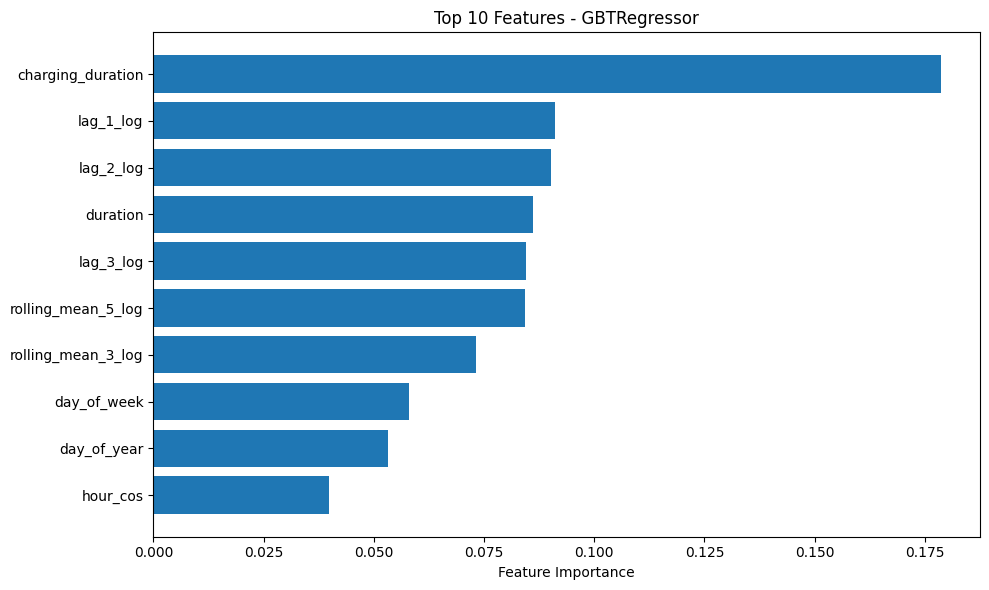

In [9]:
# ============================================================================
# STEP 8: FEATURE IMPORTANCE (GBT only)
# ============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance from GBT
try:
    feature_importance = gbt_model.featureImportances
    
    # Create sorted list
    importance_list = [(final_features[i], feature_importance[i]) 
                       for i in range(len(final_features))]
    importance_list.sort(key=lambda x: x[1], reverse=True)
    
    print("\n📊 Top 10 Most Important Features:")
    for i, (feature, importance) in enumerate(importance_list[:10], 1):
        print(f"  {i:2d}. {feature:25s}: {importance:.4f}")
    
    # Plot if matplotlib available
    try:
        import matplotlib.pyplot as plt
        
        features = [f[0] for f in importance_list[:10]]
        importances = [f[1] for f in importance_list[:10]]
        
        plt.figure(figsize=(10, 6))
        plt.barh(features, importances)
        plt.xlabel("Feature Importance")
        plt.title("Top 10 Features - GBTRegressor")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig("feature_importance.png")
        print("\n✓ Feature importance plot saved to 'feature_importance.png'")
    except:
        print("\n⚠ matplotlib not available, skipping plot")
        
except Exception as e:
    print(f"⚠ Could not extract feature importance: {e}")

In [10]:
# ============================================================================
# STEP 9: HYPERPARAMETER TUNING (Optional - improves GBT)
# ============================================================================
print("\n" + "="*80)
print("OPTIONAL: Hyperparameter Tuning for GBT")
print("="*80)

tune_models = input("\nRun hyperparameter tuning? (y/n): ").lower() == 'y'

if tune_models:
    print("\n🔧 Setting up cross-validation...")
    
    # Parameter grid
    param_grid = ParamGridBuilder() \
        .addGrid(gbt.maxDepth, [5, 10, 15]) \
        .addGrid(gbt.maxIter, [50, 100]) \
        .addGrid(gbt.stepSize, [0.05, 0.1]) \
        .build()
    
    # Cross-validator
    cv = CrossValidator(
        estimator=gbt,
        estimatorParamMaps=param_grid,
        evaluator=evaluator_mae,
        numFolds=3,
        seed=42,
        parallelism=2
    )
    
    # Run CV (may take time)
    print("Training with 3-fold CV (this may take several minutes)...")
    start_time = time.time()
    cv_model = cv.fit(train_data_featured)
    cv_time = time.time() - start_time
    
    # Best model
    best_gbt = cv_model.bestModel
    print(f"\n✓ Best parameters found:")
    print(f"  - maxDepth: {best_gbt.getMaxDepth()}")
    print(f"  - maxIter: {best_gbt.getMaxIter()}")
    print(f"  - stepSize: {best_gbt.getStepSize()}")
    
    # Evaluate best model
    best_predictions = best_gbt.transform(test_data_featured)
    best_mae = evaluator_mae.evaluate(best_predictions)
    best_rmse = evaluator_rmse.evaluate(best_predictions)
    
    print(f"\n📊 Best Model Performance:")
    print(f"  - MAE:  {best_mae:.4f} (improvement: {mae - best_mae:+.4f})")
    print(f"  - RMSE: {best_rmse:.4f}")
    
    # Compare with paper
    if best_mae < 2.66:
        print(f"\n🎉 EXCEEDS PAPER'S XGBoost! (Target: 2.66)")
    elif best_mae < 2.68:
        print(f"\n✅ BETTER THAN PAPER'S Hybrid 3! (Target: 2.68)")
    else:
        print(f"\n⚠ Still below paper's benchmarks")
else:
    print("Skipping hyperparameter tuning")


OPTIONAL: Hyperparameter Tuning for GBT



Run hyperparameter tuning? (y/n):  y



🔧 Setting up cross-validation...
Training with 3-fold CV (this may take several minutes)...


26/04/13 14:16:05 WARN BlockManager: Block rdd_4022_0 already exists on this machine; not re-adding it
26/04/13 14:18:16 WARN DAGScheduler: Broadcasting large task binary with size 1039.7 KiB
26/04/13 14:18:16 WARN DAGScheduler: Broadcasting large task binary with size 1032.5 KiB
26/04/13 14:18:17 WARN DAGScheduler: Broadcasting large task binary with size 1033.0 KiB
26/04/13 14:18:17 WARN DAGScheduler: Broadcasting large task binary with size 1033.7 KiB
26/04/13 14:18:17 WARN DAGScheduler: Broadcasting large task binary with size 1034.7 KiB
26/04/13 14:18:17 WARN DAGScheduler: Broadcasting large task binary with size 1005.2 KiB
26/04/13 14:18:17 WARN DAGScheduler: Broadcasting large task binary with size 1036.7 KiB
26/04/13 14:18:17 WARN DAGScheduler: Broadcasting large task binary with size 1018.9 KiB
26/04/13 14:18:17 WARN DAGScheduler: Broadcasting large task binary with size 1040.3 KiB
26/04/13 14:18:17 WARN DAGScheduler: Broadcasting large task binary with size 1040.4 KiB
26/04/1

In [ ]:
# ============================================================================
# STEP 10: SAVE MODELS & RESULTS
# ============================================================================
print("\n" + "="*80)
print("SAVING MODELS AND RESULTS")
print("="*80)

# Save models
model_path = "hdfs://localhost:9000/ev-project/data/models/"

# GBT model
gbt_model.save(model_path + "gbt_regressor")
print(f"✓ GBT model saved to: {model_path}gbt_regressor")

# Linear Regression model
lr_model.save(model_path + "linear_regression")
print(f"✓ Linear Regression model saved to: {model_path}linear_regression")

# Save predictions for analysis
print("\n💾 Saving predictions...")

# Add predictions to test data
test_with_preds = test_data_featured.select(
    "connectionTime", "kWhDelivered",
    gbt_predictions.prediction.alias("gbt_prediction"),
    lr_predictions.prediction.alias("lr_prediction")
)

# Save as parquet
test_with_preds.write.mode("overwrite").parquet(model_path + "test_predictions")
print(f"✓ Predictions saved to: {model_path}test_predictions")

# Sample predictions
print("\n📊 Sample predictions (first 10 rows):")
test_with_preds.show(10, truncate=False)

In [ ]:
# ============================================================================
# STEP 11: ERROR ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("ERROR ANALYSIS")
print("="*80)

# Calculate residuals
residuals = test_with_preds.withColumn(
    "gbt_residual", col("kWhDelivered") - col("gbt_prediction")
).withColumn(
    "lr_residual", col("kWhDelivered") - col("lr_prediction")
)

# Residual statistics
print("\n📊 GBT Residuals:")
residuals.select(
    mean("gbt_residual").alias("mean"),
    stddev("gbt_residual").alias("stddev"),
    min("gbt_residual").alias("min"),
    max("gbt_residual").alias("max"),
    percentile_approx("gbt_residual", 0.5).alias("median")
).show()

print("\n📊 Linear Regression Residuals:")
residuals.select(
    mean("lr_residual").alias("mean"),
    stddev("lr_residual").alias("stddev"),
    min("lr_residual").alias("min"),
    max("lr_residual").alias("max"),
    percentile_approx("lr_residual", 0.5).alias("median")
).show()

# Error by hour of day (temporal analysis)
print("\n📊 Error by Hour of Day (GBT):")
hourly_error = residuals.groupBy(hour("connectionTime").alias("hour")).agg(
    avg("gbt_residual").alias("avg_error"),
    stddev("gbt_residual").alias("stddev_error"),
    count("*").alias("count")
).orderBy("hour")

hourly_error.show(10)

In [ ]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"""
📋 Dataset Summary:
  - Total samples: {total_rows:,}
  - Features: {len(final_features)}
  - Train/Test split: 80/20

🤖 Model Performance:
  {'─' * 50}
  Linear Regression (Baseline 2):
    • MAE:  {mae_lr:.4f}
    • RMSE: {rmse_lr:.4f}
    • R²:   {r2_lr:.4f}
  
  GBTRegressor (Baseline 1 - Spark):
    • MAE:  {mae:.4f}
    • RMSE: {rmse:.4f}
    • R²:   {r2:.4f}
  {'─' * 50}

📈 Paper Benchmarks (Target):
  • XGBoost MAE: 2.66
  • Hybrid 3 (BiLSTM) MAE: 2.68

🎯 Goal Achievement:
  • GBT vs XGBoost: {((mae - 2.66)/2.66*100):+.2f}%
  • GBT vs Hybrid 3: {((mae - 2.68)/2.68*100):+.2f}%

💡 Recommendations:
  {'•' if mae < 2.68 else '○'} Continue tuning hyperparameters
  {'•' if mae < 2.66 else '○'} Add more features if possible
  {'•' if 'lag_' in final_features else '○'} Ensure lag features are correctly computed
  {'•' if mae < 2.6 else '○'} Consider ensemble methods
""")

print("\n" + "="*80)
print("✅ MODEL TRAINING COMPLETE!")
print("="*80)

# Stop Spark session
spark.stop()